# ĐỀ THI THỰC HÀNH HỌC KỲ 252 – NĂM HỌC 2025–2026  
**Môn:** Thị giác máy tính  
**Trường:** Đại học VĂN LANG  
**Khoa:** CÔNG NGHỆ THÔNG TIN  
**Ngày thi:** 03/04/2026  
**Thời gian:** 120 phút  

> (Được phép sử dụng tài liệu và laptop kết nối mạng)

**Họ tên:** Nguyễn Phước Thành 
**MSSV:** 2374802013578
**LỚP:** 0102

## Bài 1 (1 điểm)
Trình bày những nội dung cơ bản của **phép biến đổi Hough**. Lấy ví dụ thực hành (bao gồm code python)

##### Phép biến đổi Hough (Hough Transform) là một kỹ thuật trong xử lý ảnh thuộc lĩnh vực Computer Vision, dùng để phát hiện các hình dạng hình học (đường thẳng, đường tròn, ellipse…) trong ảnh.
##### Thay vì biểu diễn đường thẳng theo dạng: 𝑦=𝑎𝑥+𝑏
##### Hough sử dụng dạng cực:
𝜌=𝑥cos𝜃+𝑦sin𝜃
- 𝜌: khoảng cách từ gốc tọa độ đến đường thẳng
- 𝜃: góc của pháp tuyến
##### Không gian Hough (Hough Space):
- Mỗi điểm ảnh (𝑥,𝑦) trong ảnh → một đường sin trong không gian (𝜌,𝜃ρ,θ)
- Giao điểm của nhiều đường sin → biểu thị một đường thẳng thực trong ảnh
##### Bộ tích lũy (Accumulator):
- Tạo ma trận 2D theo (𝜌,𝜃)
- Mỗi pixel cạnh (edge pixel) sẽ “vote”
- Điểm nào có nhiều vote → khả năng cao là đường thẳng
##### Quy trình tổng quát:
1. Chuyển ảnh về grayscale
2. Phát hiện cạnh (thường dùng Canny Edge Detection)
3. Áp dụng Hough Transform
4. Tìm các đỉnh (peaks) trong accumulator
5. Vẽ lại đường phát hiện được
##### Các loại Hough Transform:
- Standard Hough Transform (SHT): chính xác nhưng chậm
- Probabilistic Hough Transform (PHT): nhanh hơn, trả về đoạn thẳng
- Hough Circle Transform: phát hiện hình tròn

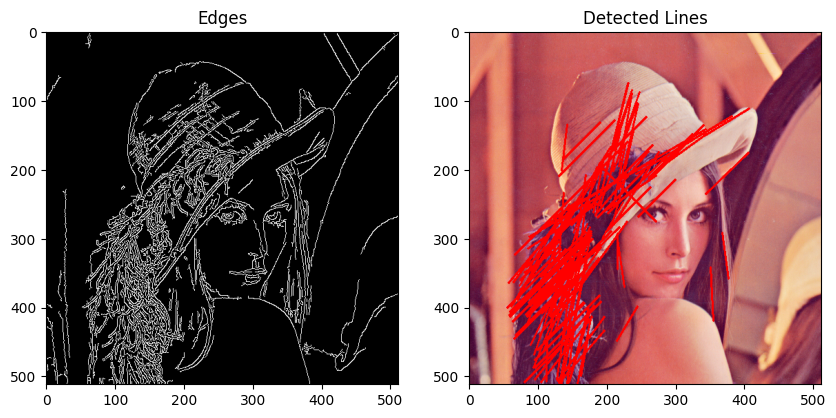

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
image = cv2.imread('lenna.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Phát hiện cạnh
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# Hough Transform (Probabilistic)
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=100,
    minLineLength=50,
    maxLineGap=10
)

# Vẽ các đường tìm được
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(image, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Hiển thị
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Edges")
plt.imshow(edges, cmap='gray')

plt.subplot(1,2,2)
plt.title("Detected Lines")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

plt.show()

## Bài 2 (1 điểm)
Trình bày những nội dung cơ bản của phương pháp nhận dạng khuôn mặt **Viola – Jones**. Lấy ví dụ thực hành (bao gồm code python) -Note: Kiểm tra khả năng tự học

##### a. Haar-like Features
- Là các đặc trưng dạng hình chữ nhật (đen – trắng)
- Mô tả sự khác biệt cường độ sáng:
    - Vùng mắt thường tối hơn má
    - Sống mũi sáng hơn hai bên
Ví dụ:
- Edge features
- Line features
- Four-rectangle features
##### b. Integral Image (Ảnh tích phân)
Giúp tính tổng pixel trong vùng rất nhanh:
𝐼(𝑥,𝑦)=∑𝑥′≤𝑥,𝑦′≤𝑦𝑖(𝑥′,𝑦′)
Tính tổng vùng bất kỳ chỉ với 4 phép toán -> tăng tốc cực mạnh
##### c. AdaBoost
AdaBoost được dùng để:
- Chọn ra feature quan trọng nhất
- Kết hợp nhiều “weak classifiers” → strong classifier
Mỗi Haar feature = 1 weak learner
##### d. Cascade Classifier
- Chuỗi nhiều tầng (stages)
- Tầng đầu: lọc nhanh (loại bỏ vùng không phải mặt)
- Tầng sau: kiểm tra kỹ hơn
 Ưu điểm: Rất nhanh vì đa số vùng bị loại sớm
##### e. Quy trình tổng quát
1. Resize + grayscale ảnh
2. Dùng sliding window quét toàn ảnh
3. Tính Haar features bằng integral image
4. Áp dụng cascade classifier
5. Vùng nào qua tất cả stage → face
##### Ưu điểm:   
- Rất nhanh (real-time)
- Không cần GPU
- Dễ triển khai
##### Nhược điểm:       
- Kém với góc nghiêng, ánh sáng phức tạp
- Không chính xác bằng Deep Learning (CNN)
- Cần dataset huấn luyện lớn

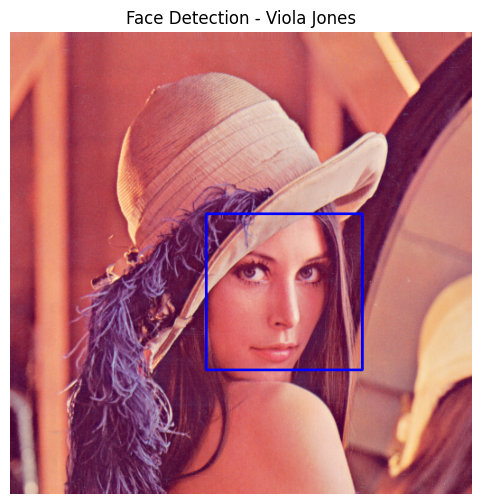

In [4]:
import cv2
import matplotlib.pyplot as plt

# Load model
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Đọc ảnh
image = cv2.imread('lenna.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect
faces = face_cascade.detectMultiScale(gray, 1.1, 5)

# Vẽ bounding box
for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 2)

# 🔥 Convert BGR -> RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Hiển thị bằng matplotlib
plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Face Detection - Viola Jones")
plt.axis("off")
plt.show()

## Bài 3 (1 điểm)
So sánh thuật toán **Meanshift** và **Camshift**. Lấy ví dụ minh họa kèm code python -Note: Kiểm tra khả năng tự học

Cả MeanShift và CamShift đều là thuật toán trong Computer Vision dùng để tracking đối tượng trong video dựa trên phân bố màu (color histogram).
##### MeanShift là thuật toán tìm điểm cực đại mật độ (mode) của phân bố xác suất.
Ý tưởng:
- Tạo histogram màu của object
- Áp dụng backprojection
 -Dịch chuyển cửa sổ (window) đến vùng có mật độ cao nhất
Đặc điểm:
- Cửa sổ kích thước cố định
- Không thay đổi shape
##### CamShift (Continuously Adaptive MeanShift) là phiên bản nâng cấp của MeanShift.
Điểm khác biệt:
- Tự động thay đổi kích thước window
- Trả về rotated bounding box

| Tiêu chí        | MeanShift  | CamShift             |
| --------------- | ---------- | -------------------- |
| Window size     | Cố định    | Thay đổi theo object |
| Rotation        | Không      | Có                   |
| Độ chính xác    | Trung bình | Cao hơn              |
| Thích ứng scale | Không      | Có                   |
| Tốc độ          | Nhanh      | Hơi chậm hơn         |
##### Quy trình chung (cả 2)
- Chọn ROI (object ban đầu)
- Tính histogram (HSV)
- Backprojection
- Áp dụng MeanShift / CamShift
- Cập nhật vị trí object
##### MeanShift phù hợp:
- Object ít thay đổi kích thước
- Môi trường ổn định
##### CamShift phù hợp:
- Object di chuyển gần/xa camera
- Tracking người, khuôn mặt

In [15]:
# MeanShift
import cv2
import numpy as np
cap = cv2.VideoCapture(0)
# Lấy frame đầu
ret, frame = cap.read()
# Chọn ROI (hardcode demo)
r, h, c, w = 200, 100, 300, 100
track_window = (c, r, w, h)
roi = frame[r:r+h, c:c+w]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
# Mask lọc màu
mask = cv2.inRange(hsv_roi, np.array((0., 60., 32.)),
                              np.array((180., 255., 255.)))

roi_hist = cv2.calcHist([hsv_roi], [0], mask, [180], [0,180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
# Điều kiện dừng hoặc nhấn ESC để thoát
term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    # Backprojection
    dst = cv2.calcBackProject([hsv], [0], roi_hist, [0,180], 1)
    # MeanShift
    ret, track_window = cv2.meanShift(dst, track_window, term_crit)
    x, y, w, h = track_window
    img = cv2.rectangle(frame, (x,y), (x+w,y+h), (255,0,0), 2)
    cv2.imshow('MeanShift Tracking', img)
    if cv2.waitKey(30) & 0xFF == 27:
        break
cap.release()
cv2.destroyAllWindows()

In [ ]:
#CamShift
import cv2
import numpy as np
cap = cv2.VideoCapture(0)
ret, frame = cap.read()
# ROI
r, h, c, w = 200, 100, 300, 100
track_window = (c, r, w, h)
roi = frame[r:r+h, c:c+w]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv_roi, np.array((0., 60., 32.)),
                              np.array((180., 255., 255.)))
roi_hist = cv2.calcHist([hsv_roi], [0], mask, [180], [0,180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    dst = cv2.calcBackProject([hsv], [0], roi_hist, [0,180], 1)

    # CamShift
    ret, track_window = cv2.CamShift(dst, track_window, term_crit)
    pts = cv2.boxPoints(ret)
    pts = pts.astype(int)
    img = cv2.polylines(frame, [pts], True, (0,255,0), 2)
    cv2.imshow('CamShift Tracking', img)
    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

## Bài 4 (2 điểm)

Cho ảnh 3-bit kích thước $5 \times 5$, bộ lọc thông thấp và bộ lọc Laplacian như hình vẽ.

Thực hiện tại điểm ảnh $(2,1)$ cho ảnh gốc, xác định:

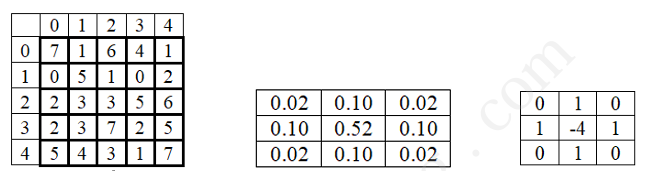

a. Giá trị sau khi áp dụng bộ lọc trung bình $3 \times 3$  
b. Giá trị sau khi áp dụng bộ lọc trung vị $3 \times 3$  
c. Giá trị sau khi áp dụng bộ lọc Laplacian  
d. Giá trị sau khi áp dụng bộ lọc thông thấp  
e. Xác định $dx, dy$  
f. Vẽ histogram của ảnh gốc  
g. Xác định ảnh sau khi cân bằng histogram

Region 3x3:
 [[0 5 1]
 [2 3 3]
 [2 3 7]]

a. Mean: 2.888888888888889
b. Median: 3.0
c. Laplacian: 1
d. Low-pass: 3.06
e. dx: 1
   dy: -2

f. Histogram:
Level 0: 2
Level 1: 4
Level 2: 4
Level 3: 4
Level 4: 2
Level 5: 4
Level 6: 2
Level 7: 3


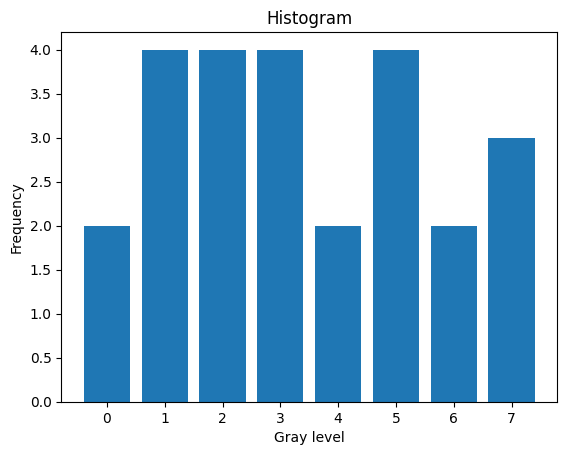


g. Mapping:
0 -> 0
1 -> 1
2 -> 2
3 -> 3
4 -> 4
5 -> 5
6 -> 6
7 -> 7

Equalized Image:
 [[7 1 6 4 1]
 [0 5 1 0 2]
 [2 3 3 5 6]
 [2 3 7 2 5]
 [5 4 3 1 7]]


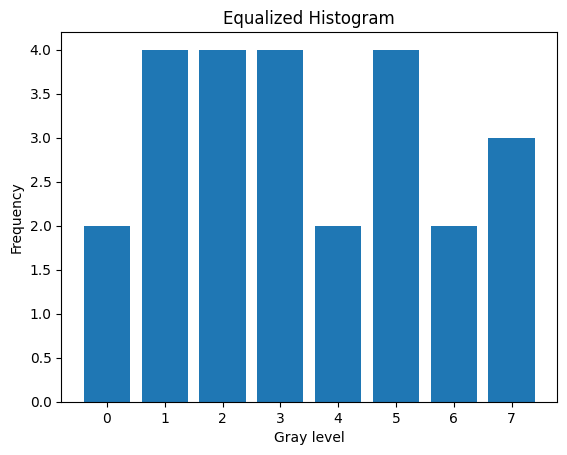

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
img = np.array([
    [7, 1, 6, 4, 1],
    [0, 5, 1, 0, 2],
    [2, 3, 3, 5, 6],
    [2, 3, 7, 2, 5],
    [5, 4, 3, 1, 7]
], dtype=np.int32)
# Điểm cần tính (row=2, col=1)
x, y = 2, 1
# Lấy vùng 3x3
region = img[x-1:x+2, y-1:y+2]
print("Region 3x3:\n", region)
# a. Mean filter
mean_val = np.mean(region)
print("\na. Mean:", mean_val)

# b. Median filter
median_val = np.median(region)
print("b. Median:", median_val)

# c. Laplacian
laplacian_kernel = np.array([
    [0, 1, 0],
    [1,-4, 1],
    [0, 1, 0]
])

laplacian_val = np.sum(region * laplacian_kernel)
print("c. Laplacian:", laplacian_val)

# d. Low-pass filter
lowpass_kernel = np.array([
    [0.02, 0.10, 0.02],
    [0.10, 0.52, 0.10],
    [0.02, 0.10, 0.02]
])

lowpass_val = np.sum(region * lowpass_kernel)
print("d. Low-pass:", lowpass_val)

# e. dx, dy
dx = img[x, y+1] - img[x, y-1]
dy = img[x+1, y] - img[x-1, y]

print("e. dx:", dx)
print("   dy:", dy)

# f. Histogram
hist = np.zeros(8, dtype=int)  # 3-bit => 0-7
for val in img.flatten():
    hist[val] += 1
print("\nf. Histogram:")
for i in range(8):
    print(f"Level {i}: {hist[i]}")

# Vẽ histogram
plt.bar(range(8), hist)
plt.title("Histogram")
plt.xlabel("Gray level")
plt.ylabel("Frequency")
plt.show()

# g. Histogram Equalization
total_pixels = img.size

pdf = hist / total_pixels
cdf = np.cumsum(pdf)

L = 8  # 3-bit
mapping = np.floor((L-1) * cdf).astype(int)
print("\ng. Mapping:")
for i in range(8):
    print(f"{i} -> {mapping[i]}")
# Áp dụng mapping
equalized_img = np.vectorize(lambda x: mapping[x])(img)
print("\nEqualized Image:\n", equalized_img)

# Vẽ histogram sau cân bằng
hist_eq = np.zeros(8, dtype=int)
for val in equalized_img.flatten():
    hist_eq[val] += 1

plt.bar(range(8), hist_eq)
plt.title("Equalized Histogram")
plt.xlabel("Gray level")
plt.ylabel("Frequency")
plt.show()

## Bài 5 (1 điểm)

Cho ảnh nhị phân kích thước $6 \times 6$, trong đó các ô trống có giá trị 0.

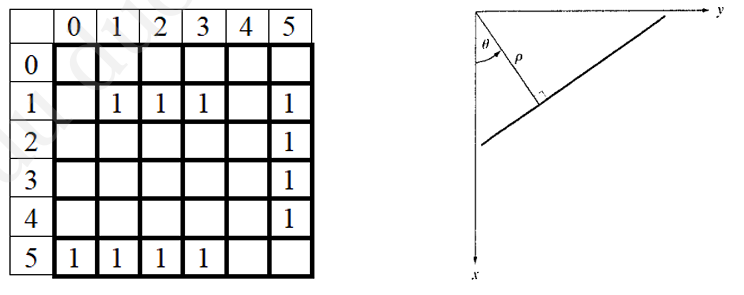

Xác định ma trận **accumulator cell**  $A(\rho,\theta)$. 
(xét các giá trị $\rho$ thích hợp và $\theta = 0^o, 45^o, 90^o$ ).

Binary Image:
 [[0 0 0 0 0 0]
 [0 1 1 1 0 1]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [1 1 1 1 0 0]]

Accumulator A(rho, theta):
rho=-9: [0 0 0]
rho=-8: [0 0 0]
rho=-7: [0 0 0]
rho=-6: [0 0 0]
rho=-5: [0 0 0]
rho=-4: [0 0 0]
rho=-3: [0 0 0]
rho=-2: [0 0 0]
rho=-1: [0 0 0]
rho= 0: [1 0 0]
rho= 1: [2 1 4]
rho= 2: [2 1 1]
rho= 3: [2 1 1]
rho= 4: [0 3 1]
rho= 5: [4 2 4]
rho= 6: [0 3 0]
rho= 7: [0 0 0]
rho= 8: [0 0 0]
rho= 9: [0 0 0]


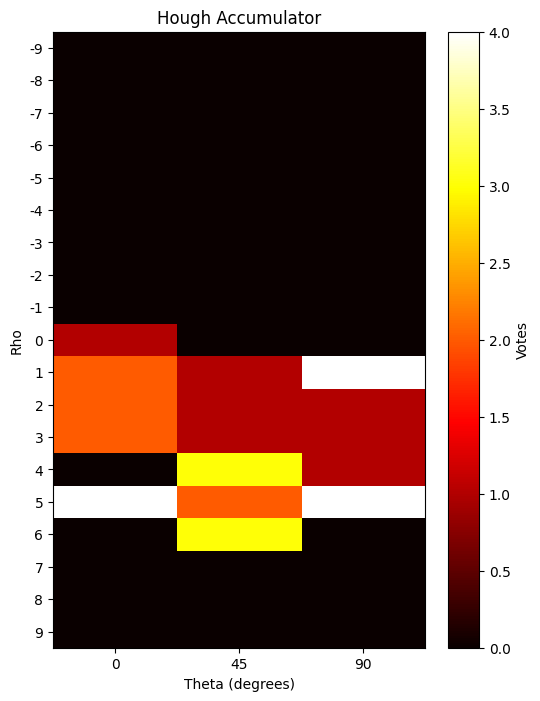

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Tạo ảnh nhị phân 6x6
img = np.zeros((6,6), dtype=int)
# Các điểm = 1 (theo đề)
points = [
    (1,1),(2,1),(3,1),(5,1),
    (5,2),(5,3),(5,4),
    (0,5),(1,5),(2,5),(3,5)
]
for (x,y) in points:
    img[y, x] = 1   

print("Binary Image:\n", img)

# 2. Khởi tạo Hough
thetas = [0, 45, 90]
theta_rad = [np.deg2rad(t) for t in thetas]
# Giới hạn rho
max_rho = int(np.ceil(np.sqrt(6**2 + 6**2)))
rhos = np.arange(-max_rho, max_rho+1)
# Accumulator
A = np.zeros((len(rhos), len(thetas)), dtype=int)

# 3. Tính accumulator
for y in range(6):
    for x in range(6):
        if img[y,x] == 1:
            for t_idx, theta in enumerate(theta_rad):
                rho = x*np.cos(theta) + y*np.sin(theta)
                rho_idx = int(round(rho)) + max_rho
                A[rho_idx, t_idx] += 1

# 4. In kết quả
print("\nAccumulator A(rho, theta):")
for i, rho in enumerate(rhos):
    print(f"rho={rho:2d}:", A[i])

# 5. Vẽ heatmap
plt.figure(figsize=(6,8))
plt.imshow(A, cmap='hot', aspect='auto')

plt.yticks(range(len(rhos)), rhos)
plt.xticks(range(len(thetas)), thetas)

plt.xlabel("Theta (degrees)")
plt.ylabel("Rho")
plt.title("Hough Accumulator")

plt.colorbar(label="Votes")
plt.show()

## Bài 6 (1.5 điểm)
Cho ảnh (bên trái) và **structuring element (SE)** (gốc tọa độ trùng với tâm SE).

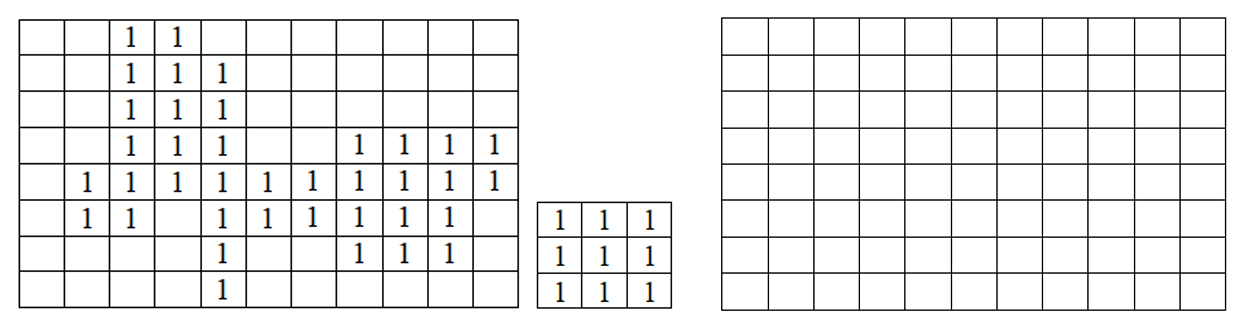

Thực hiện:
- Dilation
- Sau đó Erosion

Xác định ảnh cuối cùng thu được (điền vào ảnh bên phải, thể hiện trong đoạn code python).

In [ ]:
import numpy as np
import cv2

# 1. Tạo ảnh từ đề (bạn có thể chỉnh lại nếu cần)
img = np.array([
    [0,0,1,1,0,0,0,0,0,0,0],
    [0,0,1,1,1,0,0,0,0,0,0],
    [0,0,1,1,1,0,0,0,0,0,0],
    [0,0,1,1,1,0,0,1,1,1,1],
    [0,1,1,1,1,1,1,1,1,1,1],
    [0,1,1,0,1,1,1,1,1,1,0],
    [0,0,0,0,1,0,0,1,1,1,0],
    [0,0,0,0,1,0,0,0,0,0,0]
], dtype=np.uint8)

# 2. Structuring Element 3x3
kernel = np.ones((3,3), np.uint8)

# 3. Erosion
eroded = cv2.erode(img, kernel, iterations=1)
print("Ảnh sau erosion:\n", eroded)

Ảnh sau erosion:
 [[0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]]


## Bài 7 (1.5 điểm)

Cho mạng CNN như hình vẽ.

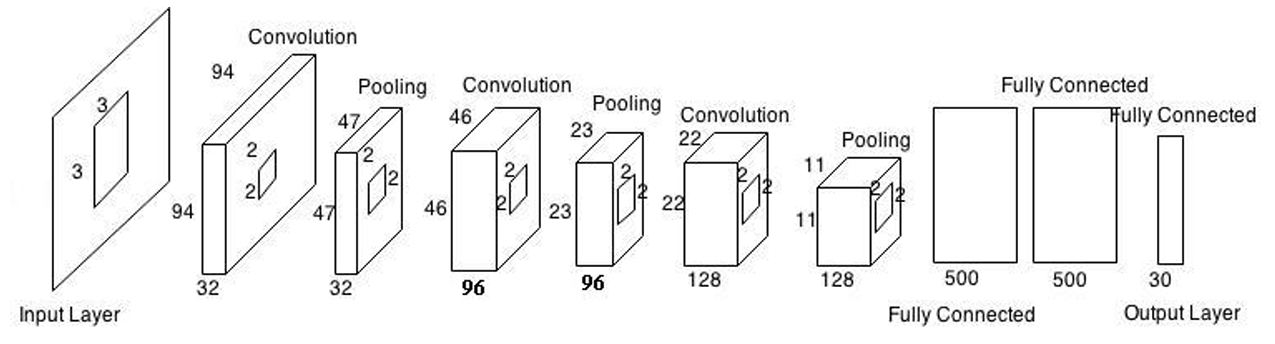

a. Có những loại lớp (layer) nào? Số lượng mỗi loại?  

b. Ảnh đầu vào có kích thước bao nhiêu?  
- Biết stride $S = 1$, số zero-padding $P = 0$  
- Ảnh màu hay ảnh xám?  

c. Lớp tích chập thứ hai:
- Có bao nhiêu kernel?  
- Kích thước mỗi kernel?  
- Tổng số tham số?  

d. Mạng có thể dùng để phân loại 35 loài động vật hay không? Tại sao?

##### a. Các loại layer:
- Convolution (Conv): 3 lớp
- Pooling: 3 lớp
- Fully Connected (FC):2 lớp
- Output layer: 1 lớp
##### b. Ảnh đầu vào
Kích thước 
Từ hình: Input → Conv → kích thước còn 94   
Dùng công thức:𝑂=(𝑁−𝐹+2𝑃)/𝑆+1   
Với:   
𝑂=94, 𝐹=3, 𝑃=0, 𝑆=1   
94=𝑁−3+1⇒𝑁=96
-> Ảnh đầu vào: 96 × 96   
Số kênh   
Sau conv đầu: depth = 32   
Kernel hiển thị là 3×3   
-> Input có dạng: 96 × 96 × 3   
Ảnh màu (RGB)
##### c. Lớp tích chập thứ hai
- Có 96 kernel
- Kích thước Kernel = 2 × 2 × 32
- Tổng số tham số (2×2×32+1)×96=(128+1)×96=129×96=12384
##### d. Không phân loại được 35 loài. Vì Số class = 35, Output Layer = 30. Muốn phân loại 35 loài động vật được thì phải đổi Output Layer thành 35

## Bài 8 (1 điểm)

Cho mạng CNN thỏa:

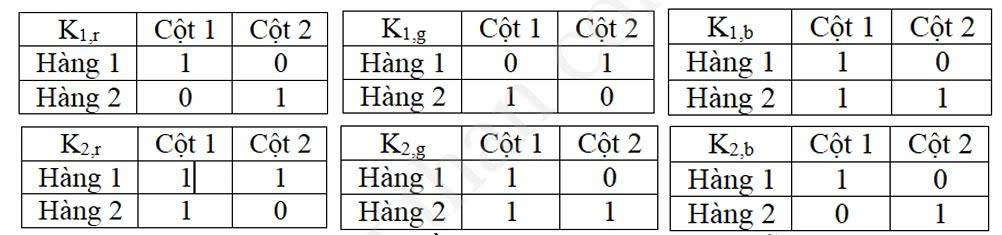

- Lớp đầu tiên là convolution
- Stride $S = 1$, zero-padding $P = 0$
- Có 2 kernel $K_1, K_2$

Ngõ vào $I$ của mạng CNN là:
- Ảnh màu gồm 3 kênh $I_r, I_g, I_b$
- Mỗi kênh kích thước $3 \times 3$

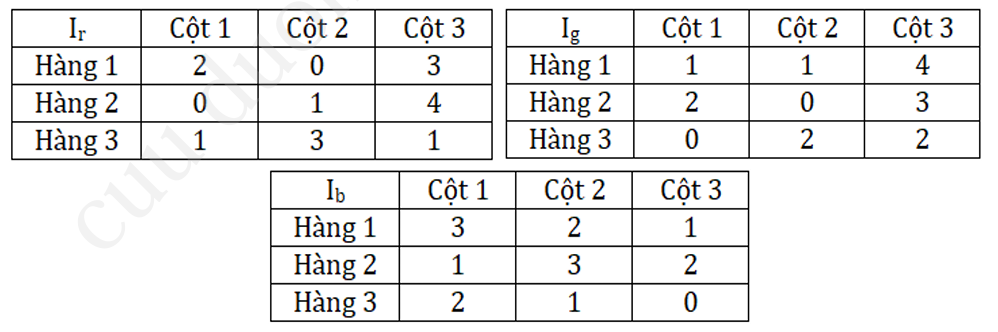

Yêu cầu:
- Xác định các activation map, biết mạng sử dụng hàm ReLU và $bias_1 = -14$, $bias_2 = -10$

> Lưu ý: Có thể tự đưa thêm giả thiết nếu cần.

Input: 3×3   
Kernel:2×2   
S=1,P=0   
O=(3−2)+1=2   
Output mỗi kernel: 2 × 2   
Vì ảnh màu (3 kênh): 𝑂𝑢𝑡𝑝𝑢𝑡=(𝐼𝑟∗𝐾𝑟)+(𝐼𝑔∗𝐾𝑔)+(𝐼𝑏∗𝐾𝑏)+𝑏𝑖𝑎𝑠   
Tính cho kernel K1
Vị trí (0,0)   
Kênh R[2 0   [1  0
       0 1] ⋅ 0  1]=2+1=3

Kênh G[1 1   [0  1
       2 0] ⋅ 1  0]=1+2=3

Kênh B[3 2   [1  0
       1 3] ⋅ 1  1]=3+1+3=7
Tổng: 3 + 3 + 7 = 13 + bias: 13-14=-1
ReLU:0
Các vị trí còn lại
| Vị trí | Giá trị trước ReLU | Sau ReLU |
| ------ | ------------------ | -------- |
| (0,0)  | -1                 | 0        |
| (0,1)  | 1                  | 1        |
| (1,0)  |-7                  | 0        |
| (1,1)  |-3                  | 0        |

Activation map K1
[0 1
0 0]

Tính cho kernel K2
| Vị trí | Trước ReLU | Sau ReLU |
| ------ | ---------- | -------- |
| (0,0)  | 1          | 1        |
| (0,1)  | 2          | 2        |
| (1,0)  | 0          | 0        |
| (1,1)  | 5          | 5        |

Activation map K2
​[6 7
7 3]



In [19]:
import numpy as np
# 1. Input (3 kênh RGB)
Ir = np.array([
    [2,0,3],
    [0,1,4],
    [1,3,1]
])
Ig = np.array([
    [1,1,4],
    [2,0,3],
    [0,2,2]
])
Ib = np.array([
    [3,2,1],
    [1,3,2],
    [2,1,0]
])

# 2. Kernel K1
K1_r = np.array([[1,0],[0,1]])
K1_g = np.array([[0,1],[1,0]])
K1_b = np.array([[1,0],[1,1]])
bias1 = -14

# 3. Kernel K2
K2_r = np.array([[1,1],[1,0]])
K2_g = np.array([[1,0],[1,1]])
K2_b = np.array([[1,0],[0,1]])
bias2 = -10
# 4. Hàm ReLU
def relu(x):
    return np.maximum(0, x)

# 5. Hàm convolution 3 kênh
def conv3channel(Ir, Ig, Ib, Kr, Kg, Kb, bias):
    H, W = Ir.shape
    out = np.zeros((H-1, W-1))
    for i in range(H-1):
        for j in range(W-1):
            region_r = Ir[i:i+2, j:j+2]
            region_g = Ig[i:i+2, j:j+2]
            region_b = Ib[i:i+2, j:j+2]
            val = (
                np.sum(region_r * Kr) +
                np.sum(region_g * Kg) +
                np.sum(region_b * Kb)
            )
            val = val + bias
            out[i,j] = relu(val)
    return out
out1 = conv3channel(Ir, Ig, Ib, K1_r, K1_g, K1_b, bias1)
out2 = conv3channel(Ir, Ig, Ib, K2_r, K2_g, K2_b, bias2)

# 7. In kết quả
print("Activation map K1:\n", out1)
print("\nActivation map K2:\n", out2)

Activation map K1:
 [[0. 1.]
 [0. 0.]]

Activation map K2:
 [[1. 2.]
 [0. 5.]]
